# Notebook 08 — Interventions and Outliers

**References:** W&H §11.1–11.3; Petris §3.6

**New engine function:** `engine.interventions.kalman_filter_interventions`

Three canonical intervention types:
- **Level shift** — add a known delta to the state prior mean at time t
- **Variance inflation** — multiply W_t by a scale factor at time t
- **Outlier** — multiply V_t by a large scale at time t (downweights obs)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from engine.filter import kalman_filter
from engine.interventions import Intervention, kalman_filter_interventions
from engine.models import make_local_level
from engine.simulate import simulate

## 1. Level Shift

At time $t$ we know the series shifts by $\delta$. We encode this by
modifying the prior state mean before the update step:

$$a_t^* = a_t + \delta \, e_j$$

where $e_j$ is the unit vector selecting the level component.

Without this adjustment, the filter must learn the shift from the data,
producing a smeared step in the filtered mean over several time steps.
With the intervention, the filter instantly accounts for the shift.

**Reference:** W&H §11.1

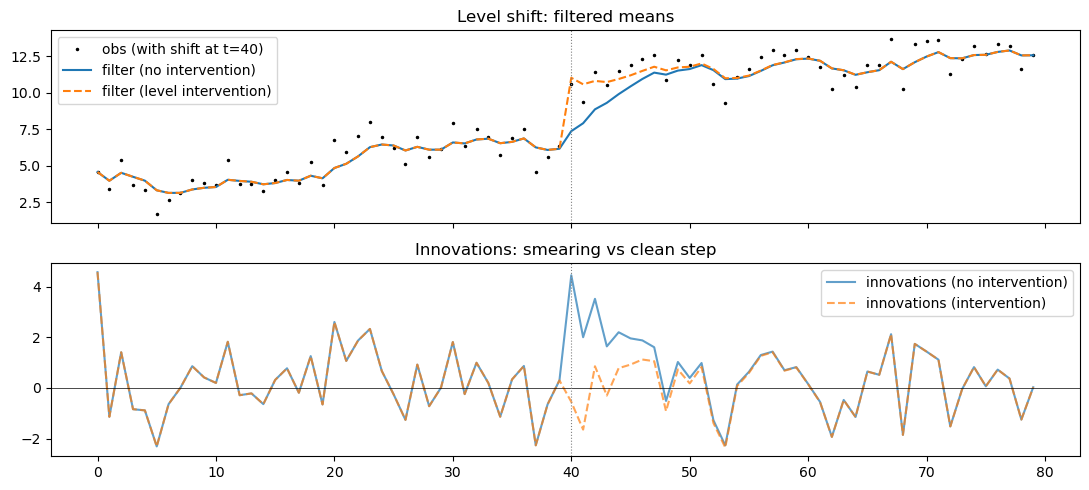

In [2]:
spec = make_local_level(V=1.0, W_level=0.1)
sim = simulate(spec, n=80, seed=0)
y = sim.y.copy()
y[40:] += 5.0  # inject level shift

fr_plain = kalman_filter(spec, y)
fr_iv = kalman_filter_interventions(
    spec, y, {40: Intervention(kind="level", delta=5.0, component=0)}
)

t = np.arange(80)
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(t, y[:, 0], "k.", ms=3, label="obs (with shift at t=40)")
axes[0].plot(t, fr_plain.m[:, 0], label="filter (no intervention)")
axes[0].plot(t, fr_iv.m[:, 0], label="filter (level intervention)", ls="--")
axes[0].axvline(40, color="gray", ls=":", lw=0.8)
axes[0].legend()
axes[0].set_title("Level shift: filtered means")
axes[1].plot(t, fr_plain.e[:, 0], label="innovations (no intervention)", alpha=0.7)
axes[1].plot(t, fr_iv.e[:, 0], label="innovations (intervention)", ls="--", alpha=0.7)
axes[1].axhline(0, lw=0.5, color="k")
axes[1].axvline(40, color="gray", ls=":", lw=0.8)
axes[1].legend()
axes[1].set_title("Innovations: smearing vs clean step")
plt.tight_layout()
plt.show()

## 2. Outlier / Variance-Inflation Model

At time $t$, an outlier intervention sets $V_t \leftarrow \omega V$ for large $\omega$,
strongly downweighting the observation. The posterior mean at time $t$ is pulled
much less toward the spike.

This approximates the exact outlier treatment (lambda-omega model, W&H §11.3)
where the observation is a mixture of in-model and outlier distributions.

**Reference:** W&H §11.3

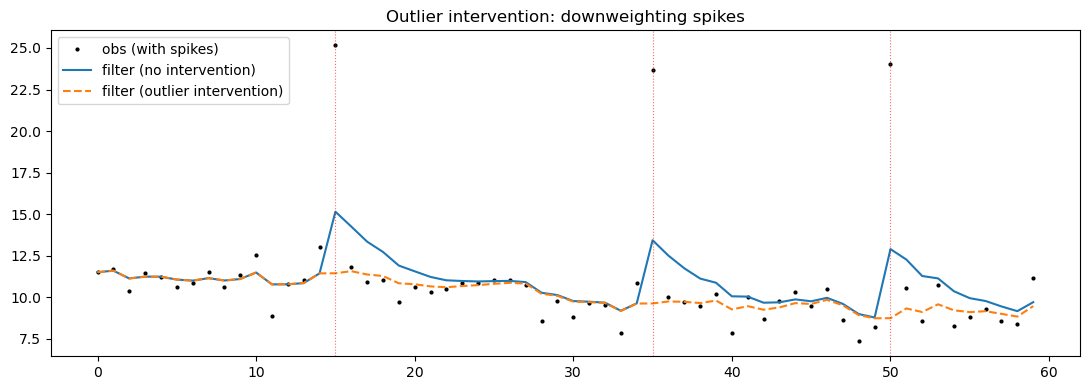

In [3]:
spec2 = make_local_level(V=1.0, W_level=0.1)
sim2 = simulate(spec2, n=60, seed=1)
y2 = sim2.y.copy()
outlier_times = [15, 35, 50]
for t_out in outlier_times:
    y2[t_out, 0] += 15.0

fr2_plain = kalman_filter(spec2, y2)
iv_dict = {t_out: Intervention(kind="outlier", scale=1000.0) for t_out in outlier_times}
fr2_iv = kalman_filter_interventions(spec2, y2, iv_dict)

t2 = np.arange(60)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t2, y2[:, 0], "k.", ms=4, label="obs (with spikes)")
ax.plot(t2, fr2_plain.m[:, 0], label="filter (no intervention)")
ax.plot(t2, fr2_iv.m[:, 0], label="filter (outlier intervention)", ls="--")
for t_out in outlier_times:
    ax.axvline(t_out, color="red", ls=":", lw=0.8, alpha=0.6)
ax.legend()
ax.set_title("Outlier intervention: downweighting spikes")
plt.tight_layout()
plt.show()

## Exercises

**Exercise 1** — Simulate a series with three injected outliers.
Apply the outlier filter and verify that the innovations at the outlier
time steps are dramatically smaller with the intervention.

```python
# YOUR CODE HERE
# spec = make_local_level(V=1.0, W_level=0.1)
# sim = simulate(spec, n=80, seed=5)
# y = sim.y.copy()
# Inject spikes at t=20, 45, 60 with amplitude 20
# Show that |fr_iv.e[20]| < |fr_plain.e[20]|
```

**Exercise 2** — Variance inflation vs outlier:
For a single large observation, compare the filtered mean at t+1 when
using `kind="variance"` vs `kind="outlier"`. How do the posteriors differ?

**Exercise 3 (challenge)** — Implement the two-component approximate mixture
filter: for each time step, compute the posterior outlier probability
pi_t using log-sum-exp and compare it across the three injected outlier times.

In [4]:
# Exercise 1 scaffold
# YOUR CODE HERE